In [13]:
from highz_exp.s_params import S_Params
import os
import glob
from skrf import Network
from os.path import join as pjoin
import pandas as pd

In [14]:
data_dir = os.path.expanduser("~/Desktop/High-Z")

In [15]:
def load_and_save_gain(data_dir, plot_dir=None, prefix='LNA'):
    files = []
    labels = []
    for file in glob.glob(pjoin(data_dir, '*.s2p')) + glob.glob(pjoin(data_dir, 'LNA*.S2P')):
        label = os.path.basename(file)
        # prefix = label.split('.')[0]
        if plot_dir is not None and not os.path.exists(plot_dir):
            os.makedirs(plot_dir)
        files.append(file)
        labels.append(label)
    s_params = S_Params(files, labels=labels)
    s_params.plot_gain(save_path=pjoin(plot_dir, prefix + '.png'), marker_freqs=[100, 200],
        type='s21', 
        y_range=(0, 15))

In [71]:
def load_and_save_reflection(data_dirs, plot_dir=None, labels=[], title='Smith Chart'):
    files = []
    for data_dir in data_dirs:
        for file in glob.glob(pjoin(data_dir, 'Ant1.s1p')) + glob.glob(pjoin(data_dir, 'Ant1_far.s1p')):
            files.append(file)
            prefix = os.path.basename(file).split('.')[0]
    if plot_dir is not None and not os.path.exists(plot_dir):
        os.makedirs(plot_dir)
    s_params = S_Params(files, labels=labels)
    s_params.plot_smith_chart(title=title,
        save_path=pjoin(plot_dir, prefix + '_smith.png'), marker_freqs=[100e6],
        s_type='s11', freq_range=(10, 250))
    s_params.plot_impedance(save_path=pjoin(plot_dir, prefix + '_impedance.png'), s_type='s11', freq_range=(10, 250))

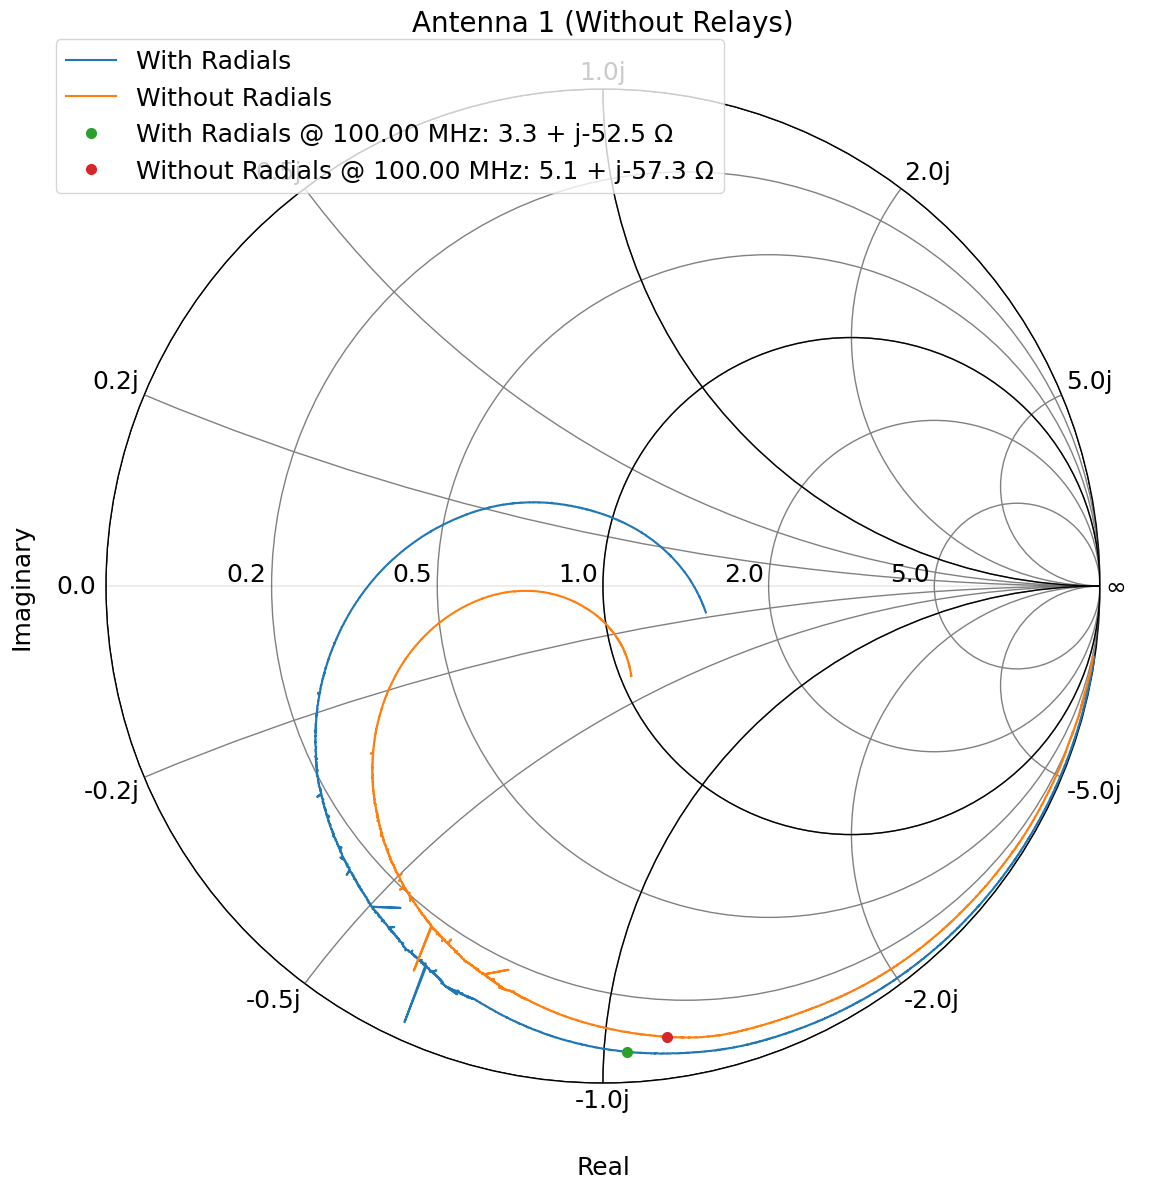

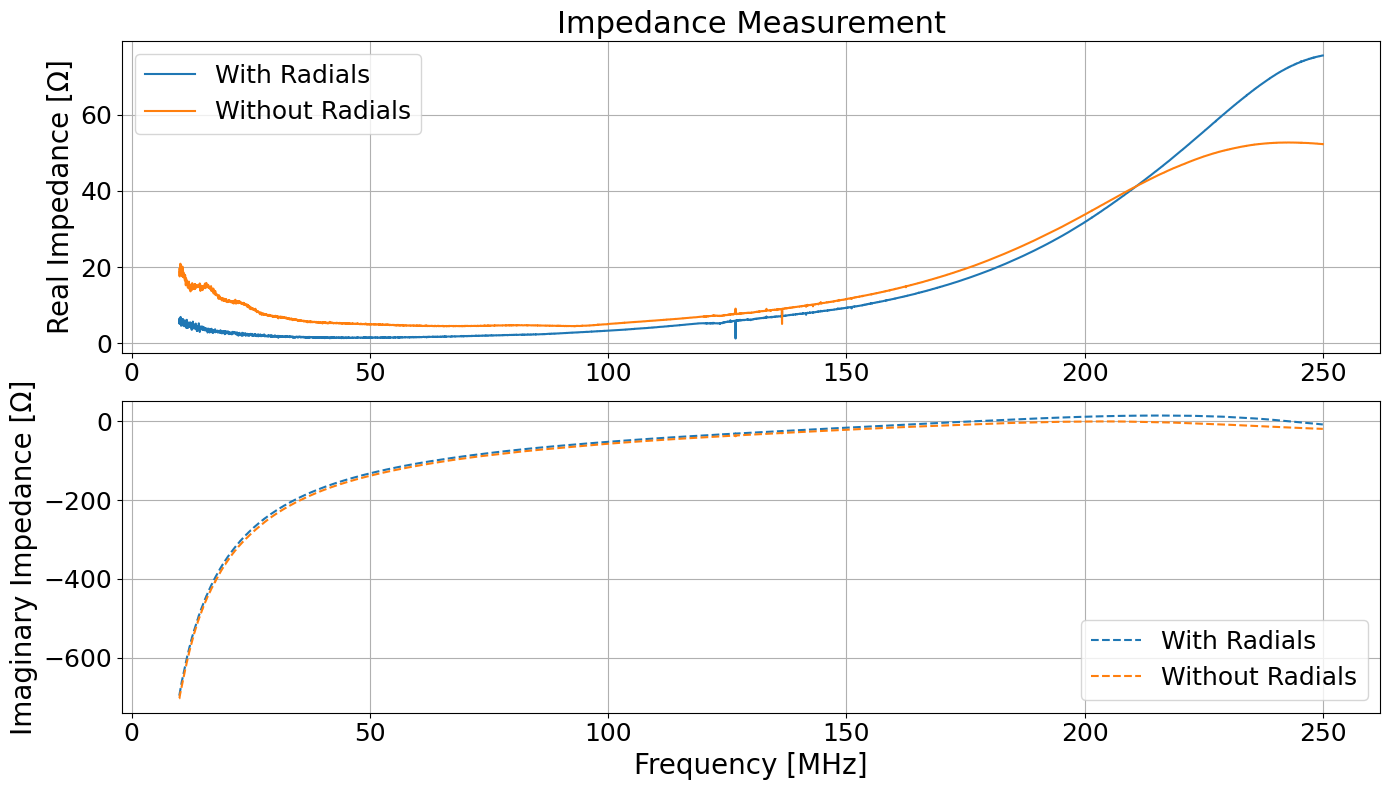

In [72]:
load_and_save_reflection([pjoin(data_dir, 'woRelays_wRadials'), 
                         pjoin(data_dir, 'woRelays_woRadials')],
                         plot_dir=pjoin(os.path.expanduser("~/Desktop/High-Z"), 'plots'),
                         labels=['With Radials', 'Without Radials'],
                         title='Antenna 1 (Without Relays)')

In [39]:
df = pd.read_csv(pjoin(data_dir, 'RFBox1', 'RELAY1_NF_ANT.csv'))

Text(0.5, 1.0, 'Relay board #1 Antenna Path')

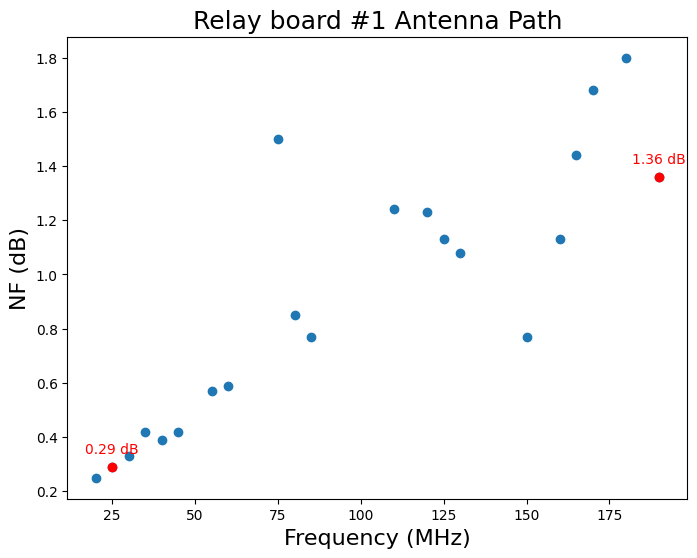

In [56]:
from matplotlib import pyplot as plt
import numpy as np

x = df['Frequency (MHz)'].values
y = df['NF (dB)'].values

plt.figure(figsize=(8, 6))
plt.scatter(x, y)
marker_freqs = [25, 190]
for marker_freq in marker_freqs:
    idx = np.argmin(np.abs(x - marker_freq))
    plt.scatter(x[idx], y[idx], color='red')
    plt.annotate(f'{y[idx]:.2f} dB', (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center',
                 color='red')
plt.xlabel('Frequency (MHz)', fontdict={'size': 16})
plt.ylabel('NF (dB)', fontdict={'size': 16})
plt.title('Relay board #1 Antenna Path', fontdict={'size': 18})

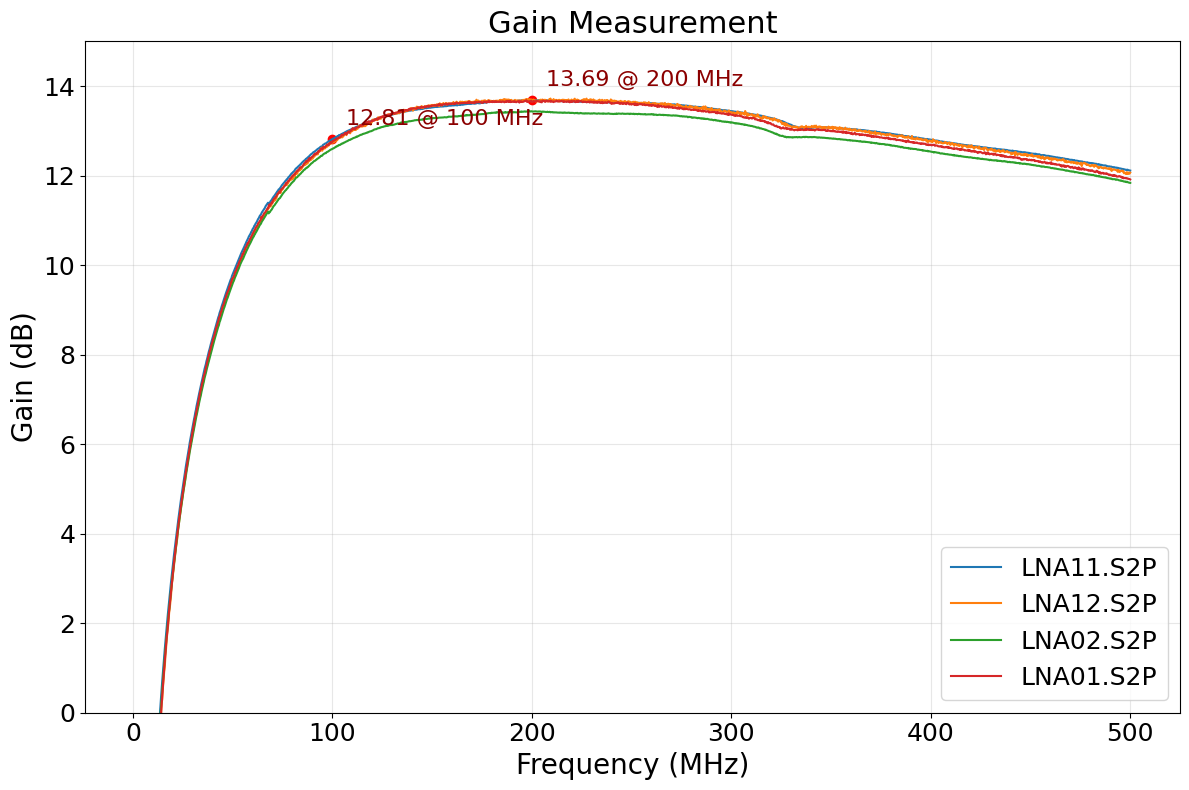

In [31]:
load_and_save_gain(pjoin(data_dir, 'VNA'), plot_dir=pjoin(data_dir, 'plots'))

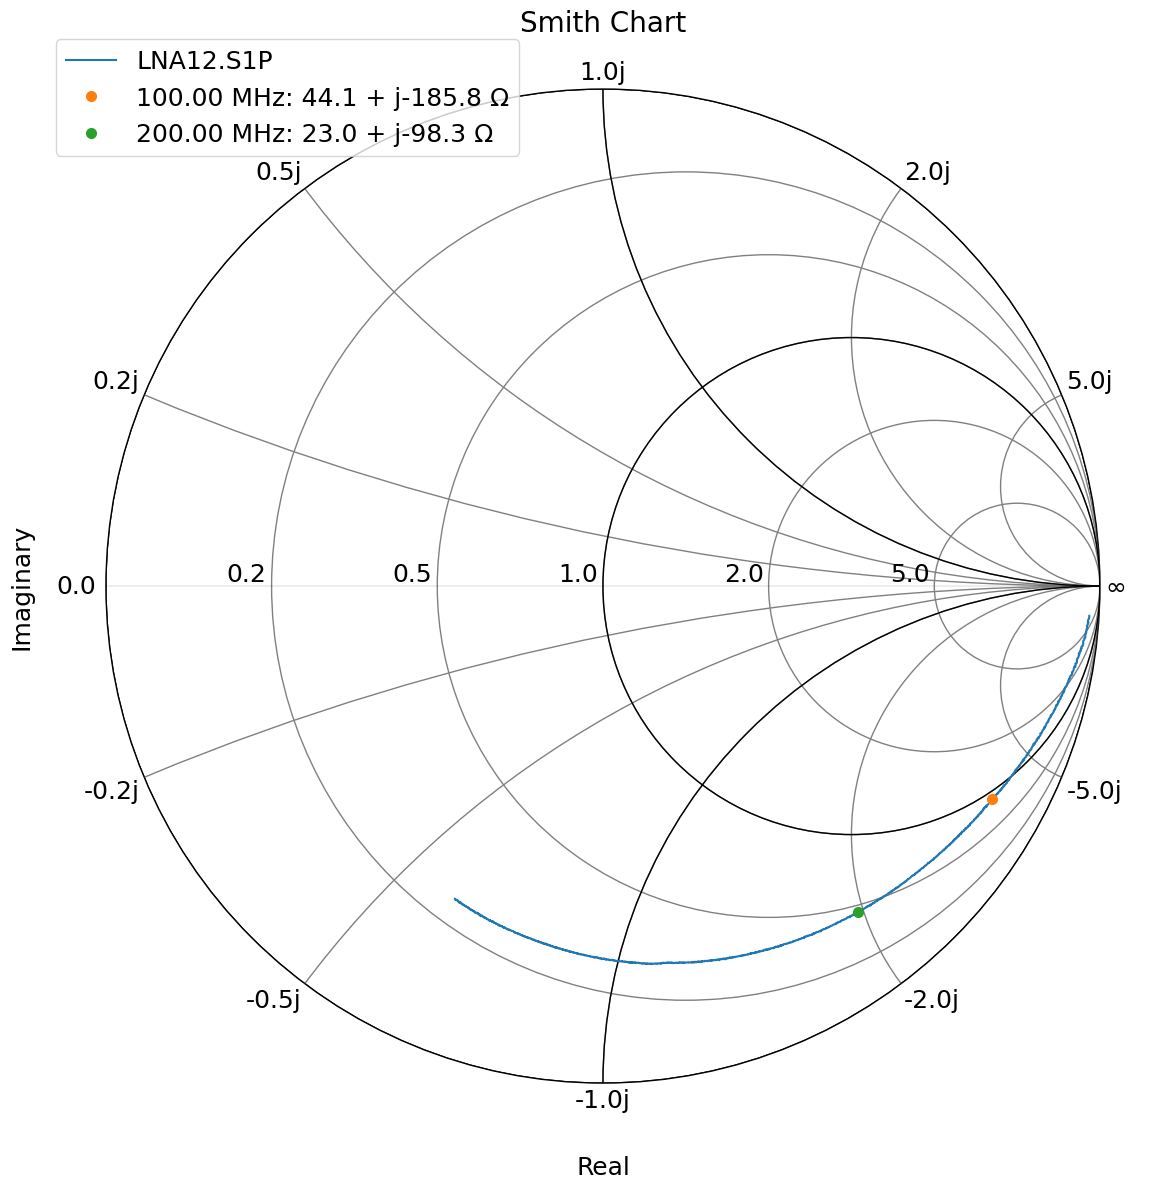

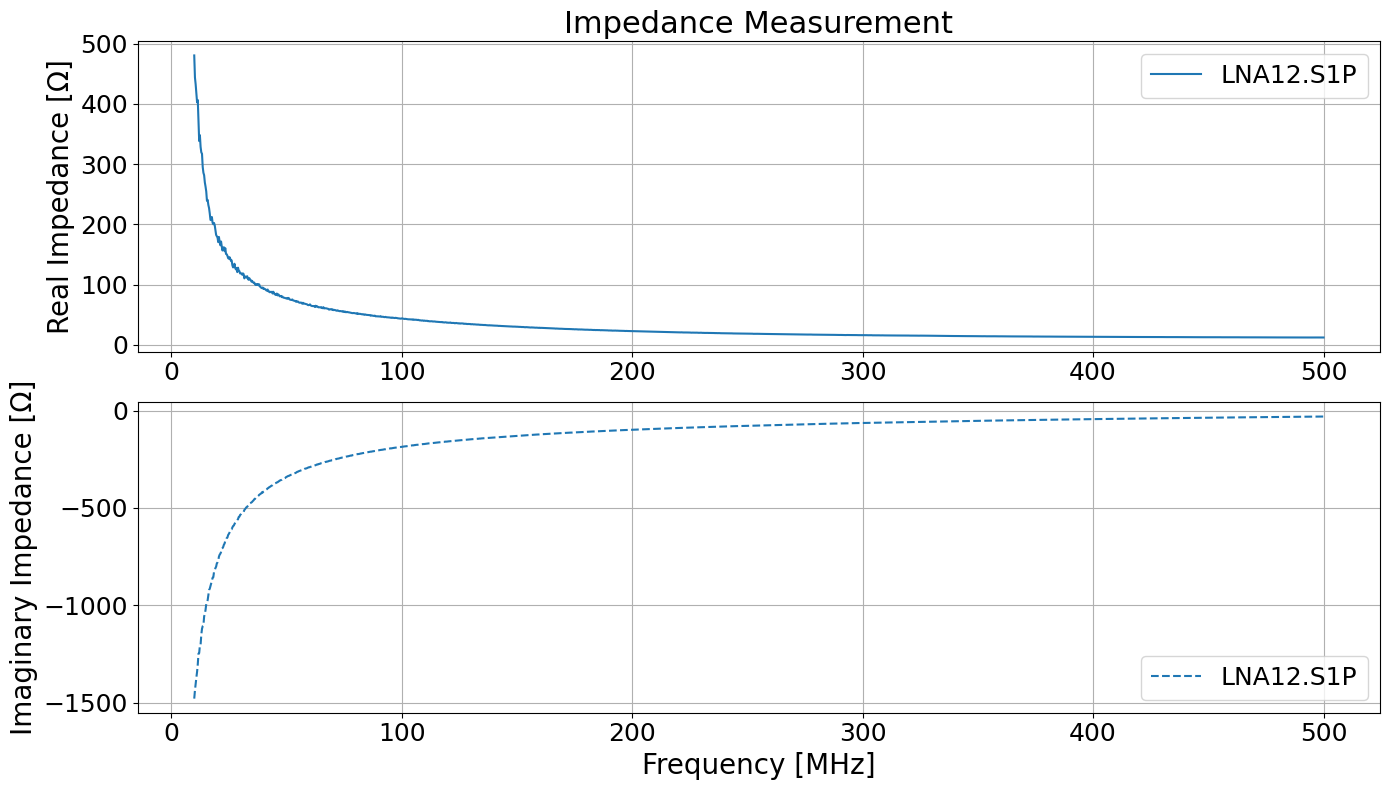

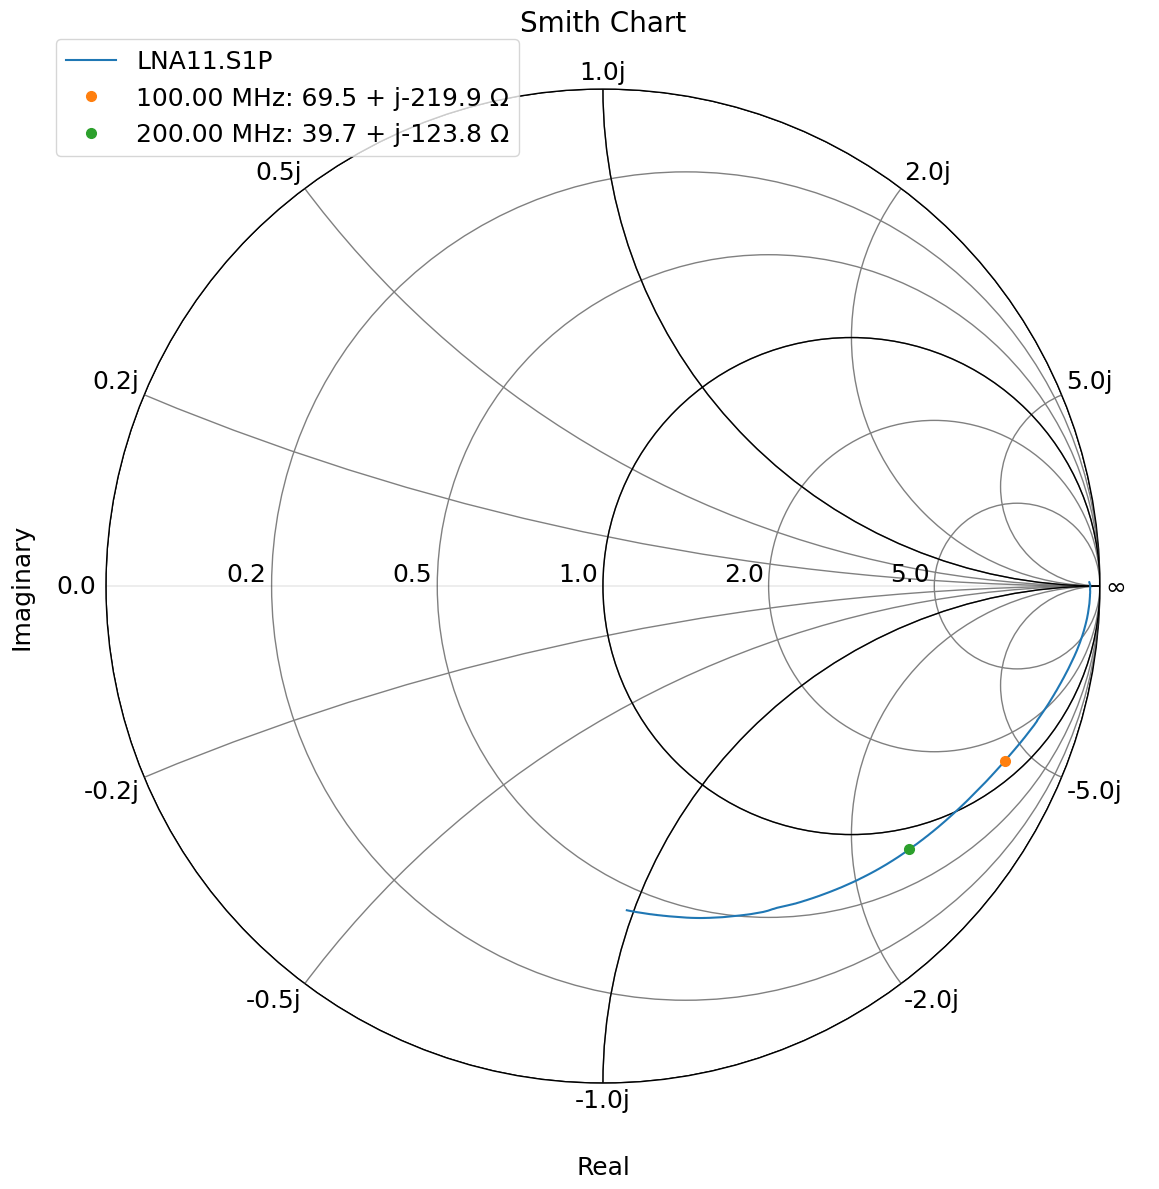

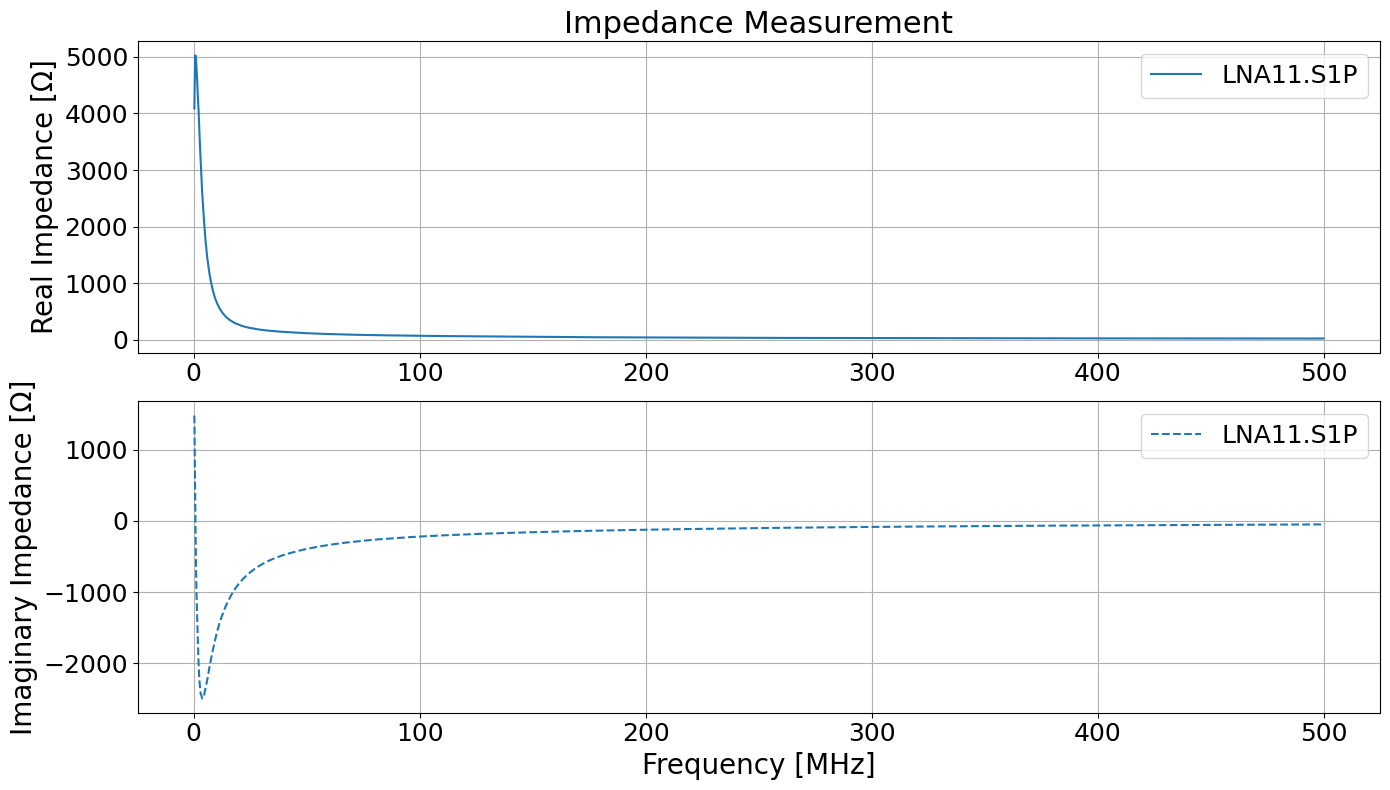

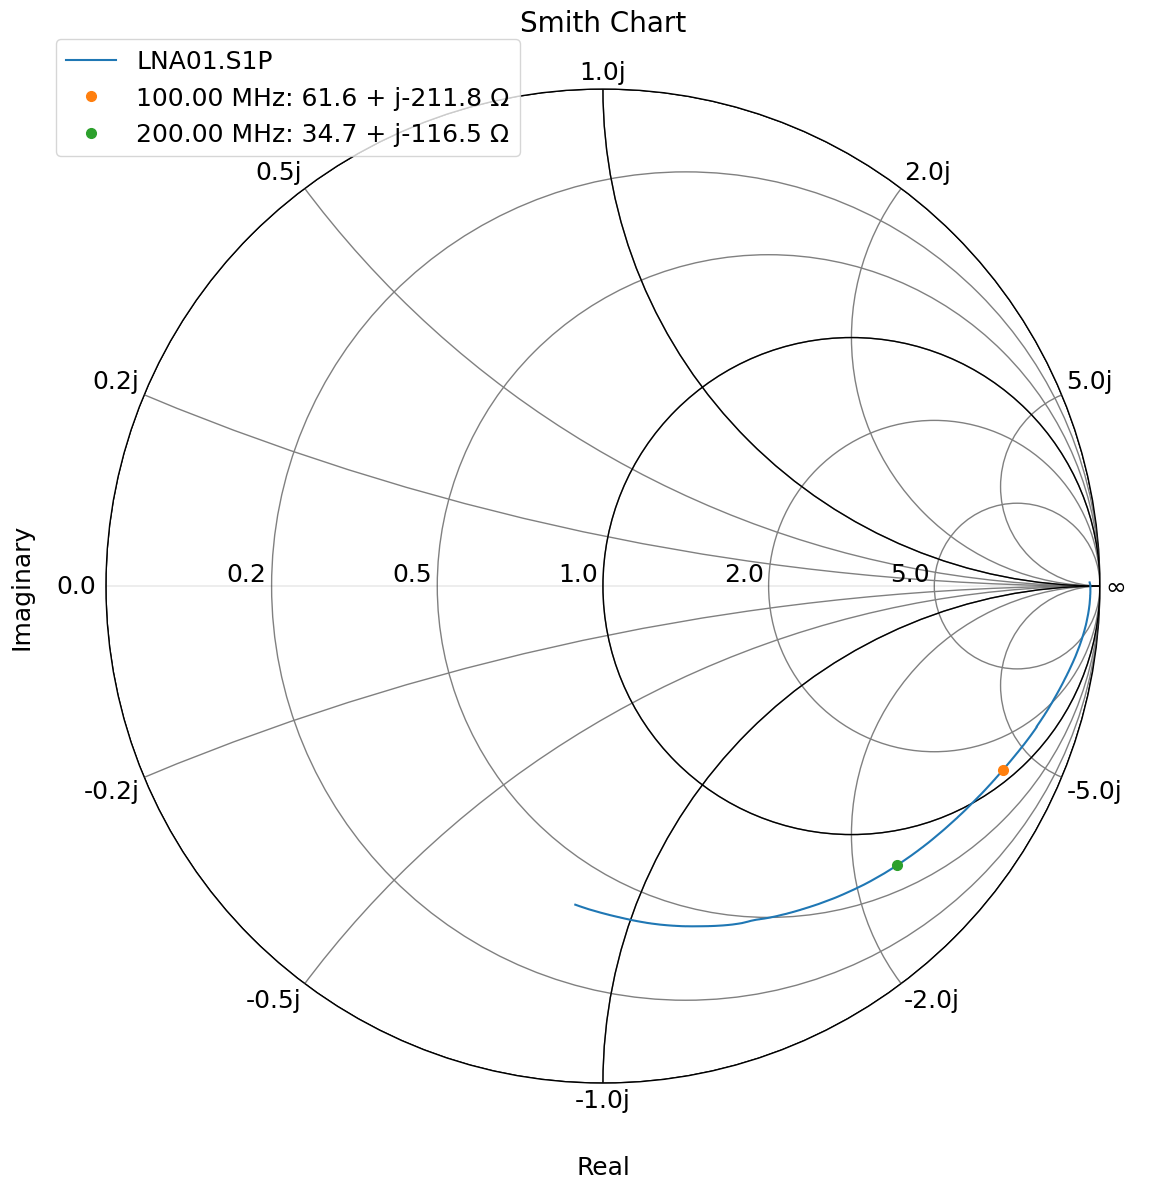

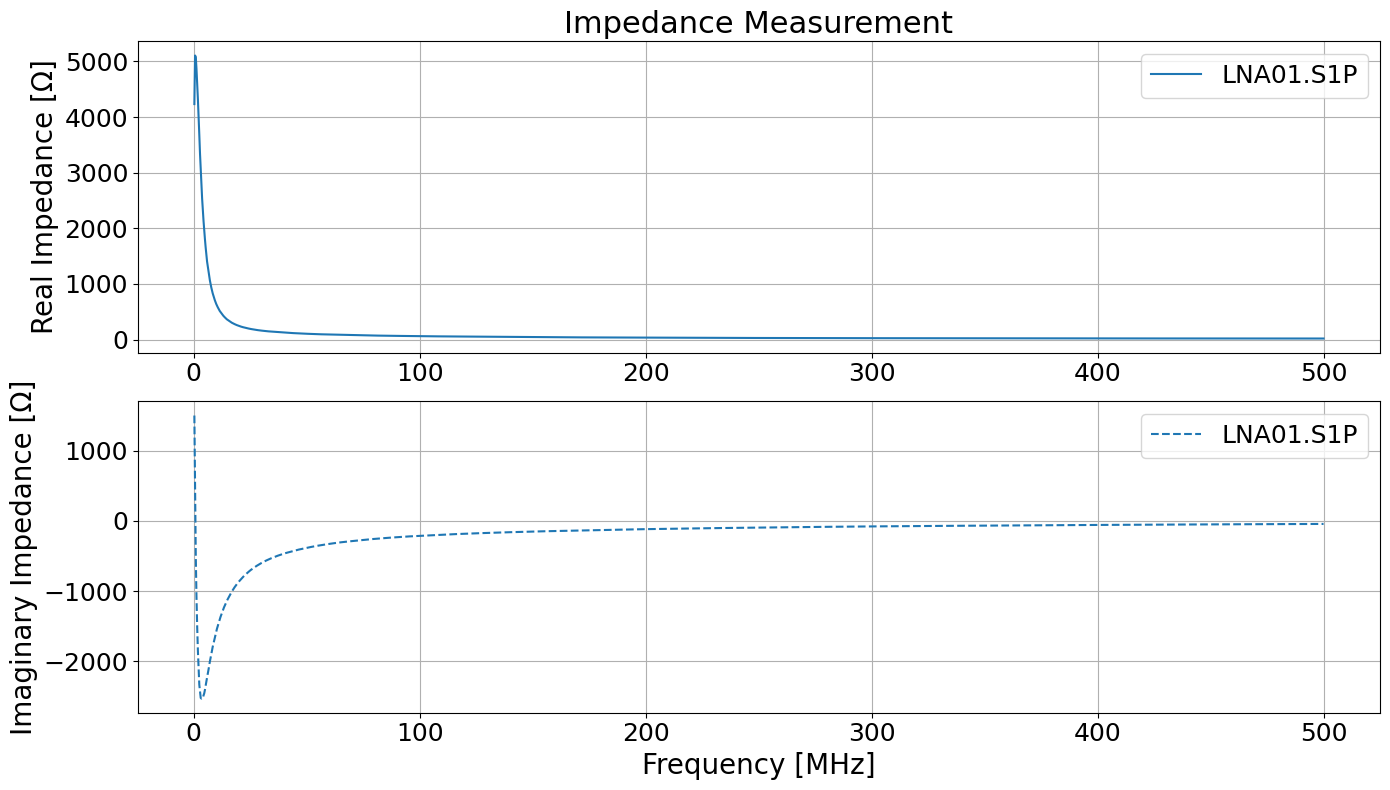

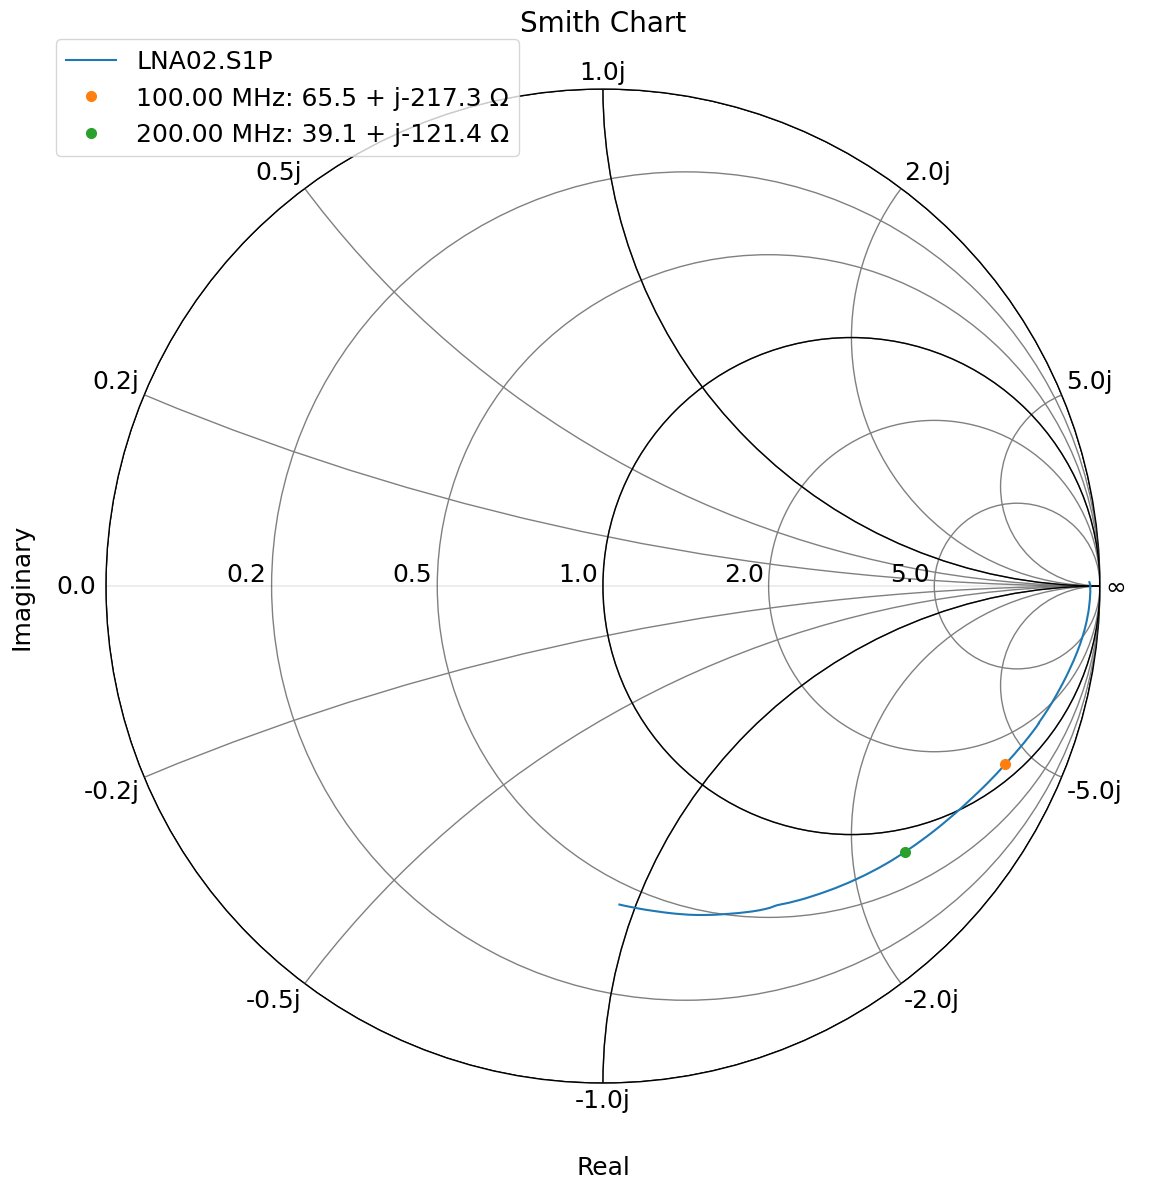

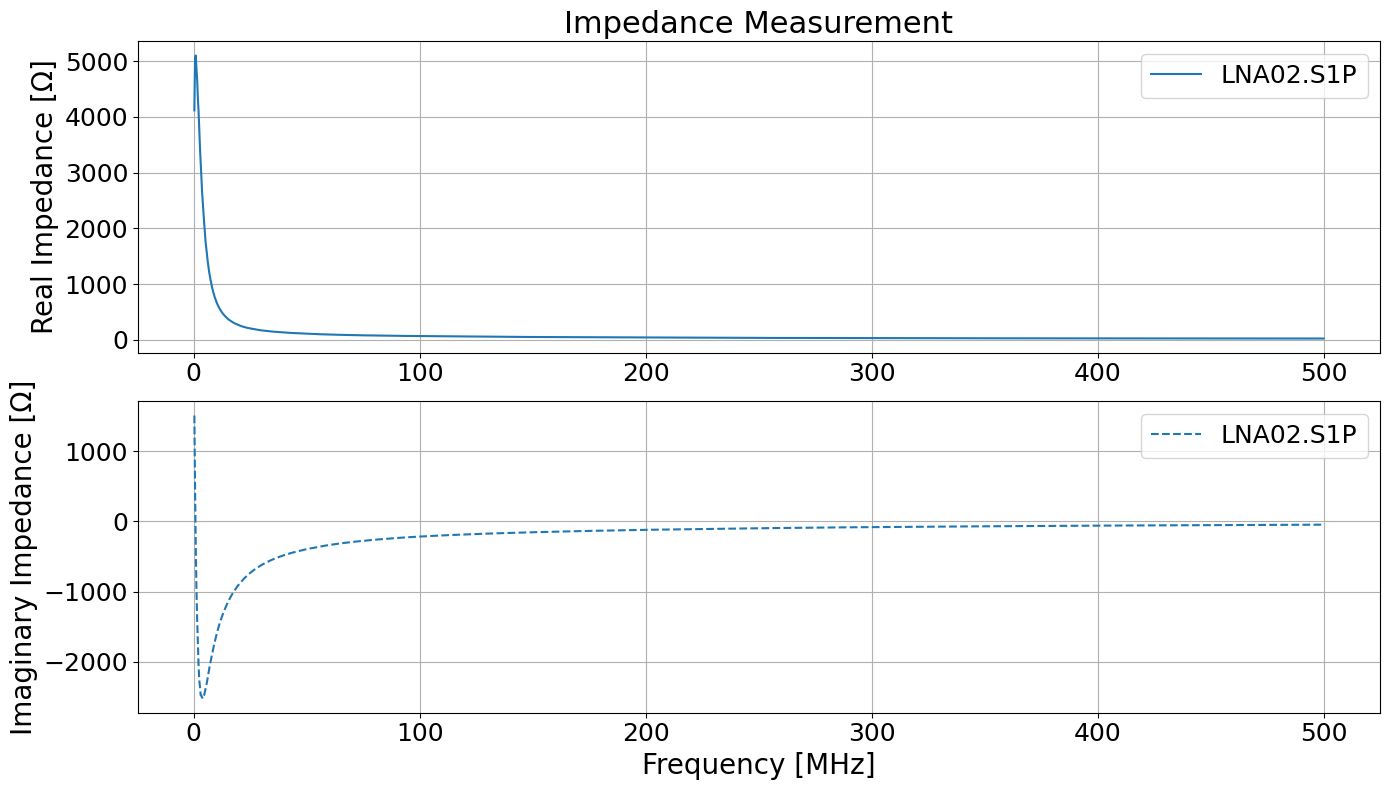

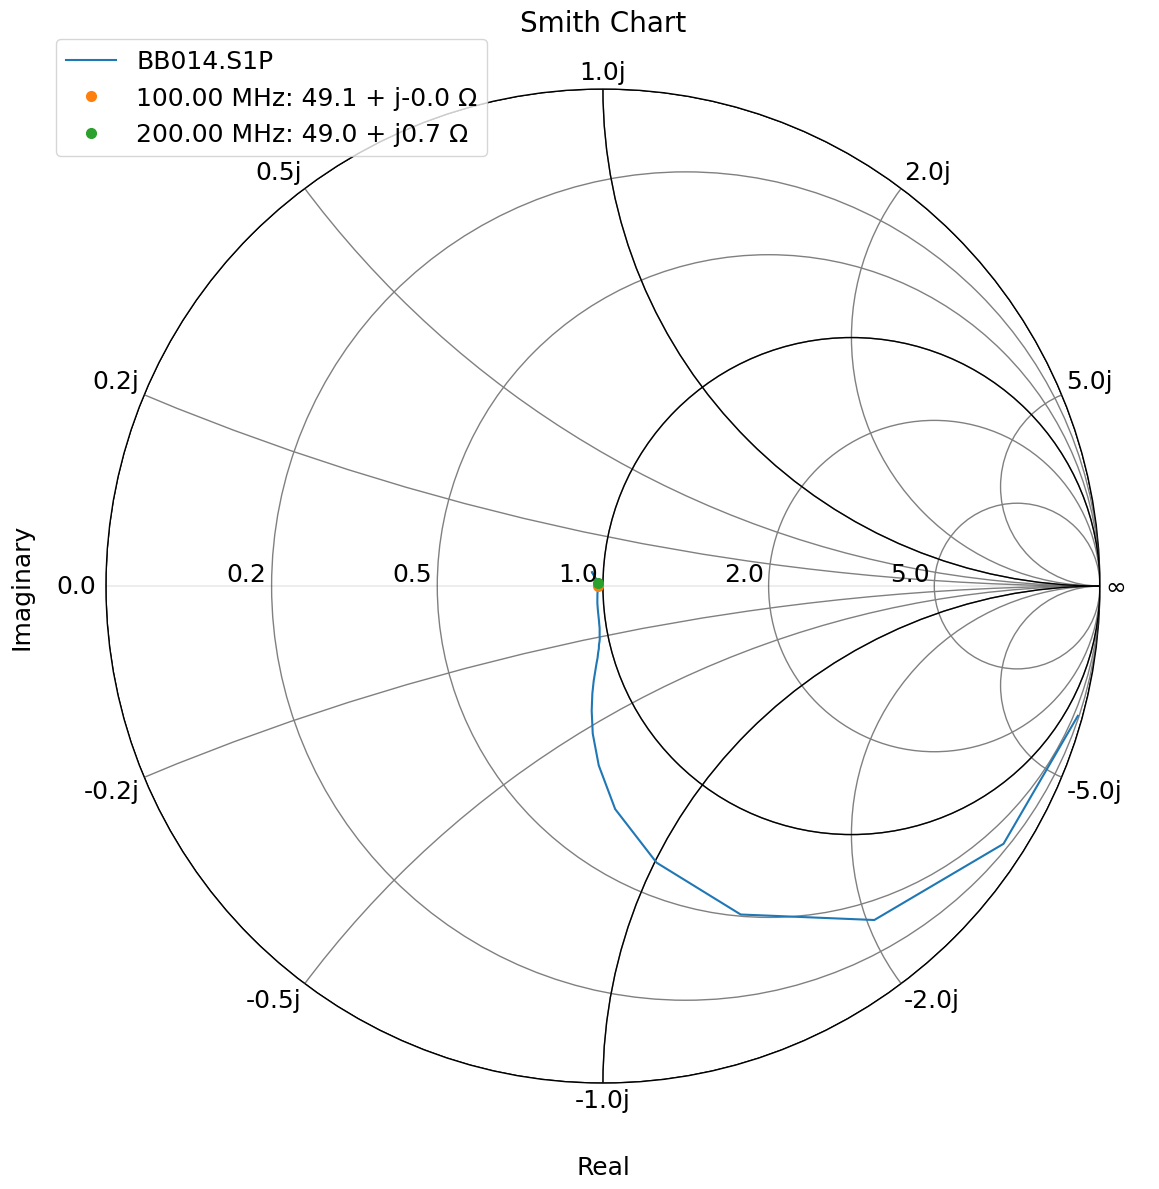

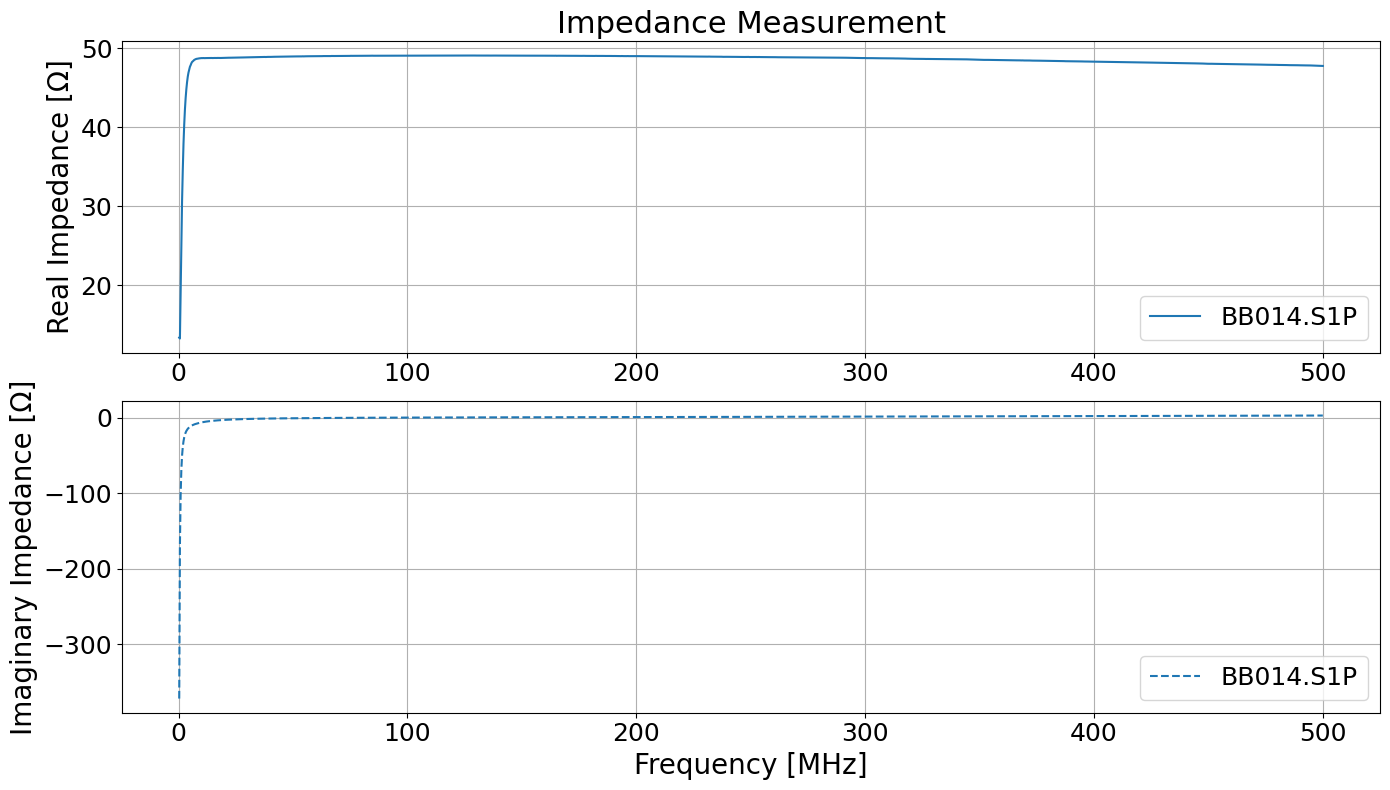

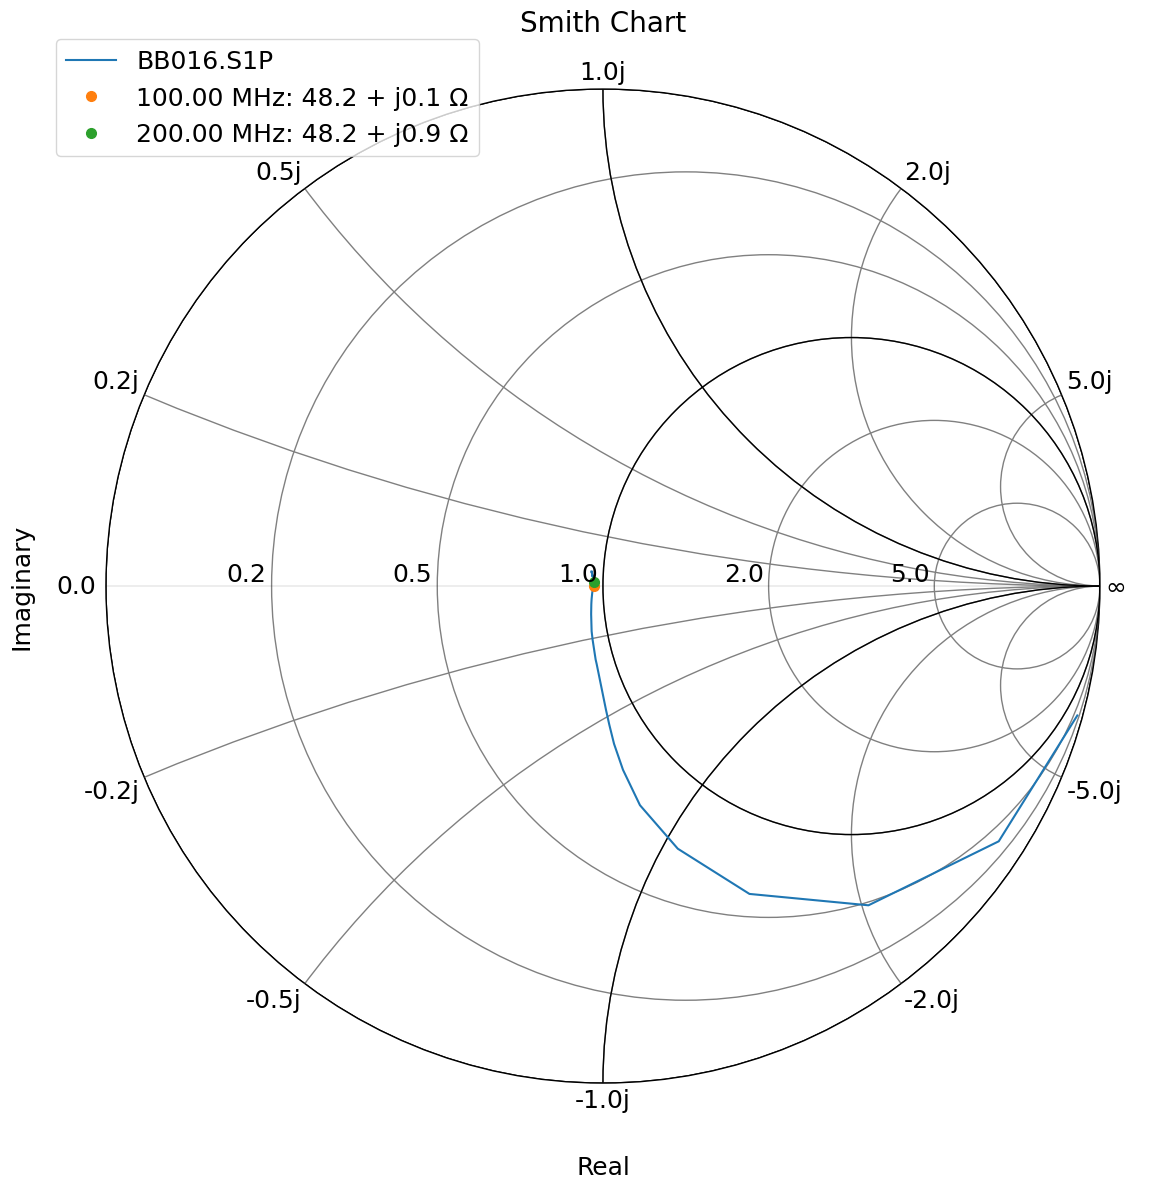

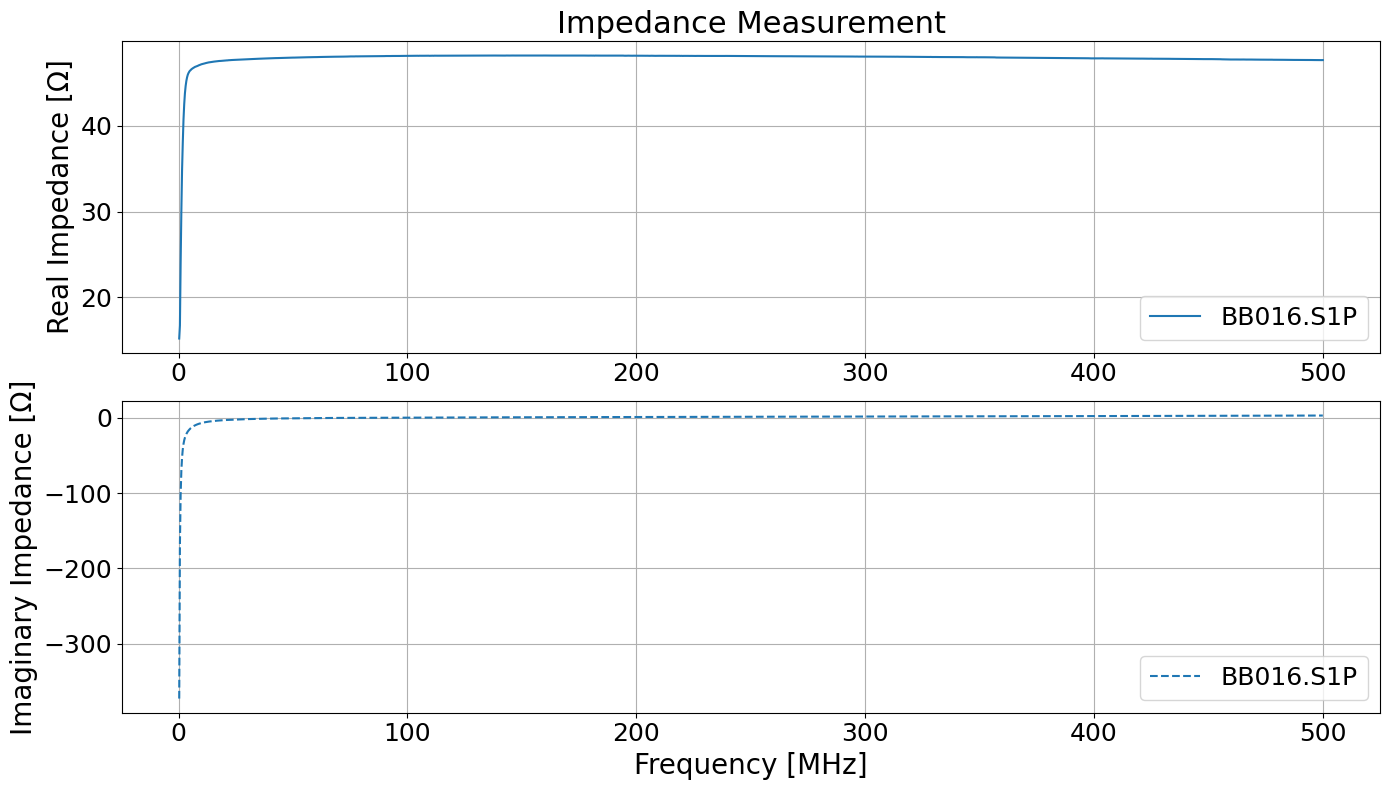

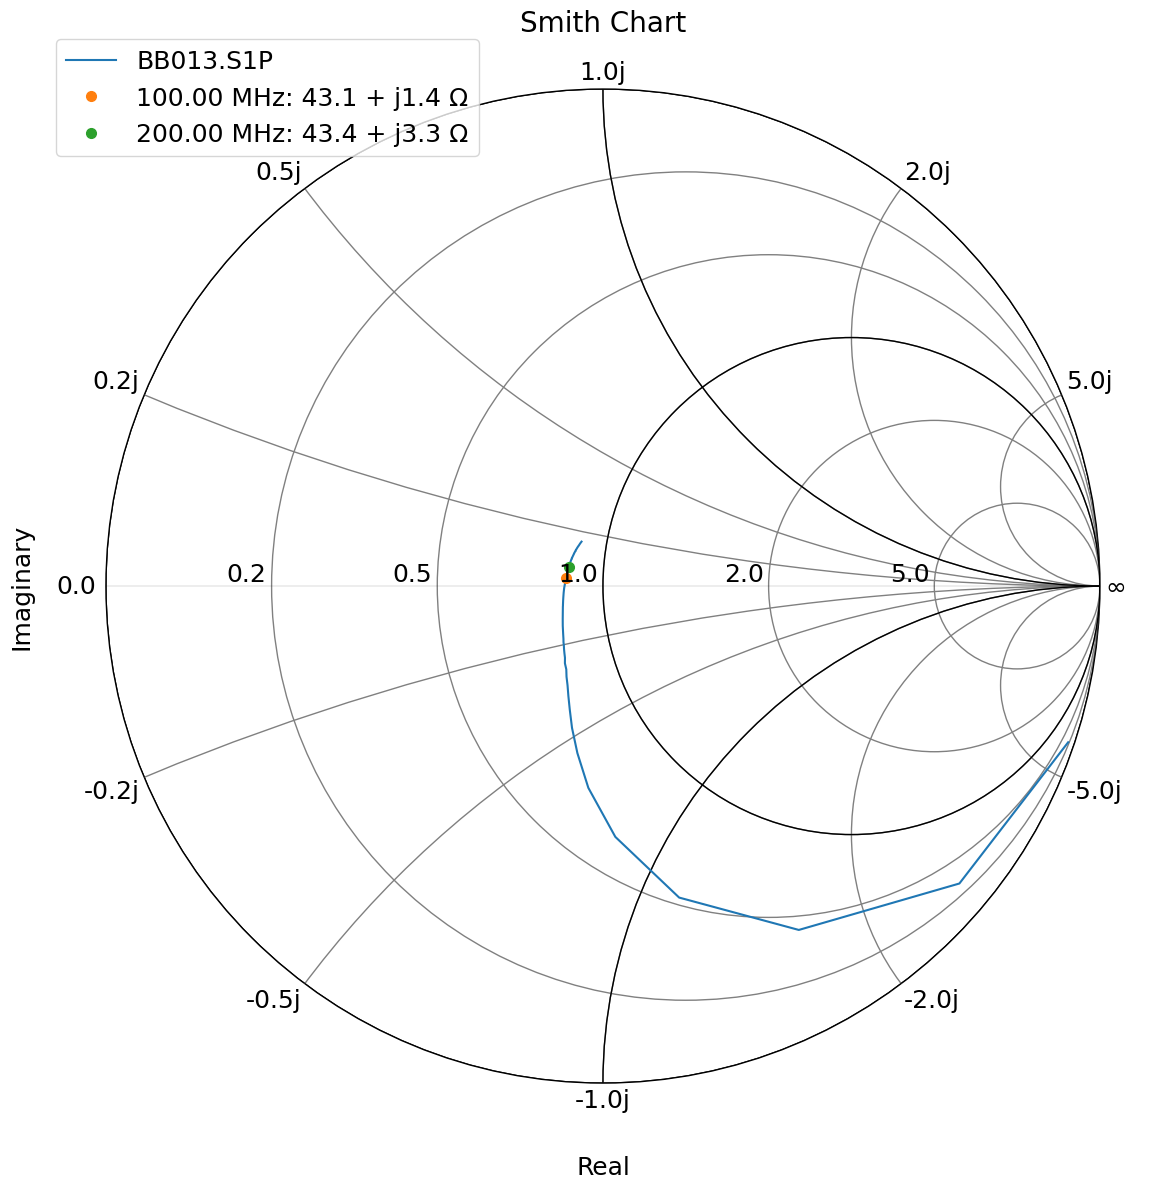

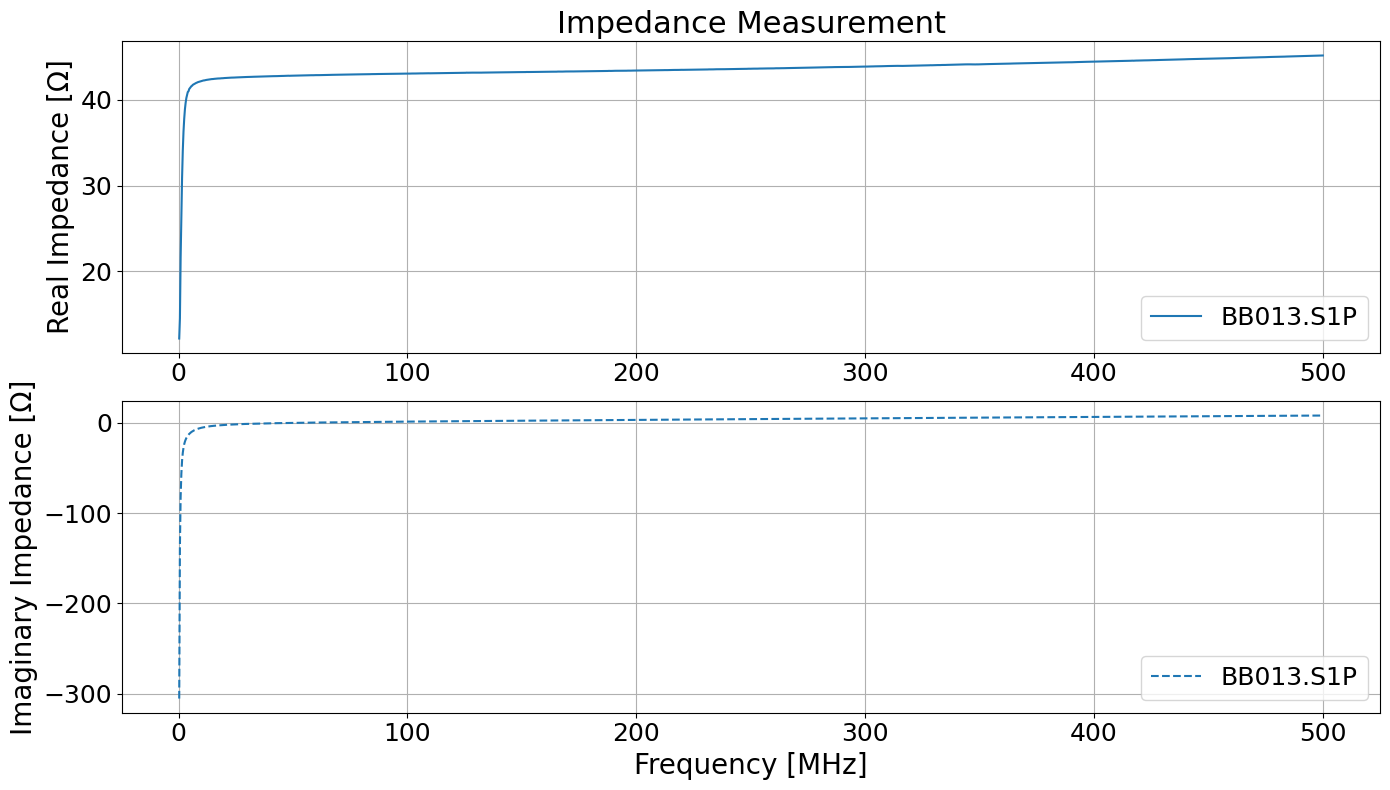

In [27]:
load_and_save_reflection(pjoin(data_dir, 'VNA'),
                         plot_dir=pjoin(data_dir, 'reflection_plots'))

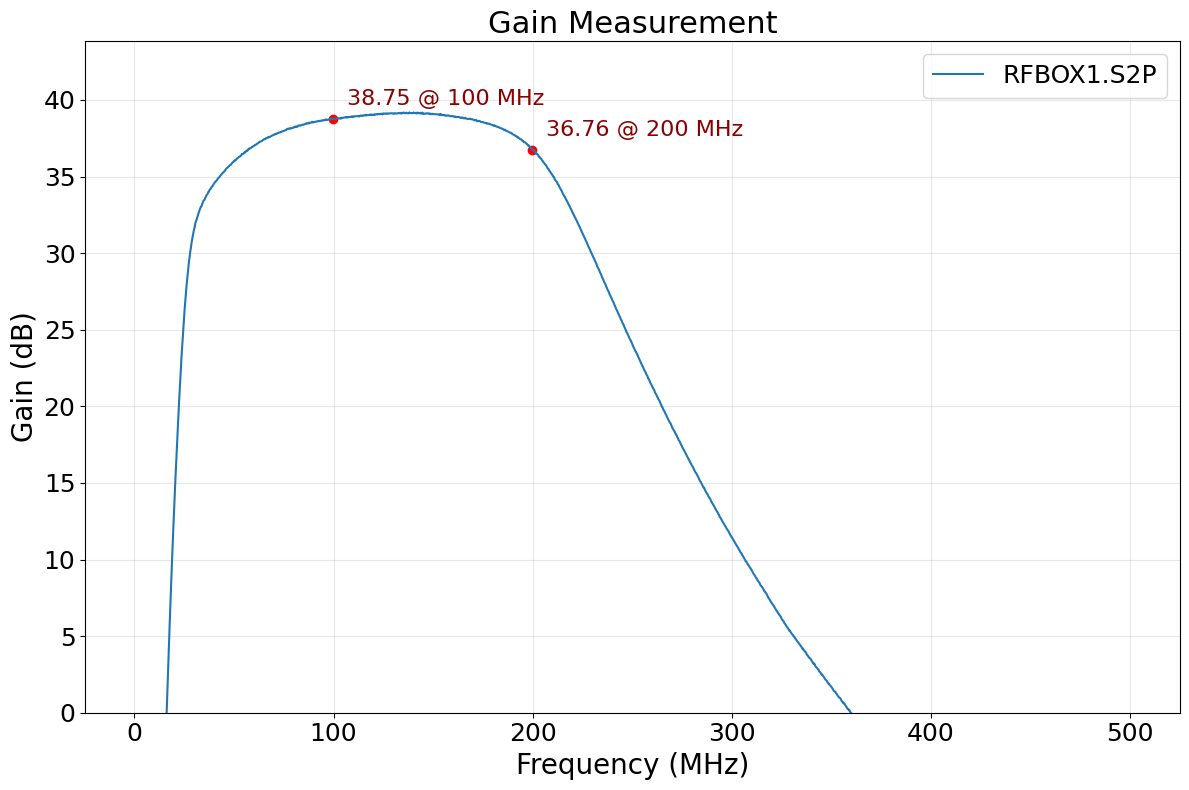

In [17]:
load_and_save_gain(pjoin(data_dir, 'RFBox1'), 
                   plot_dir=pjoin(data_dir, 'gain_plots'))

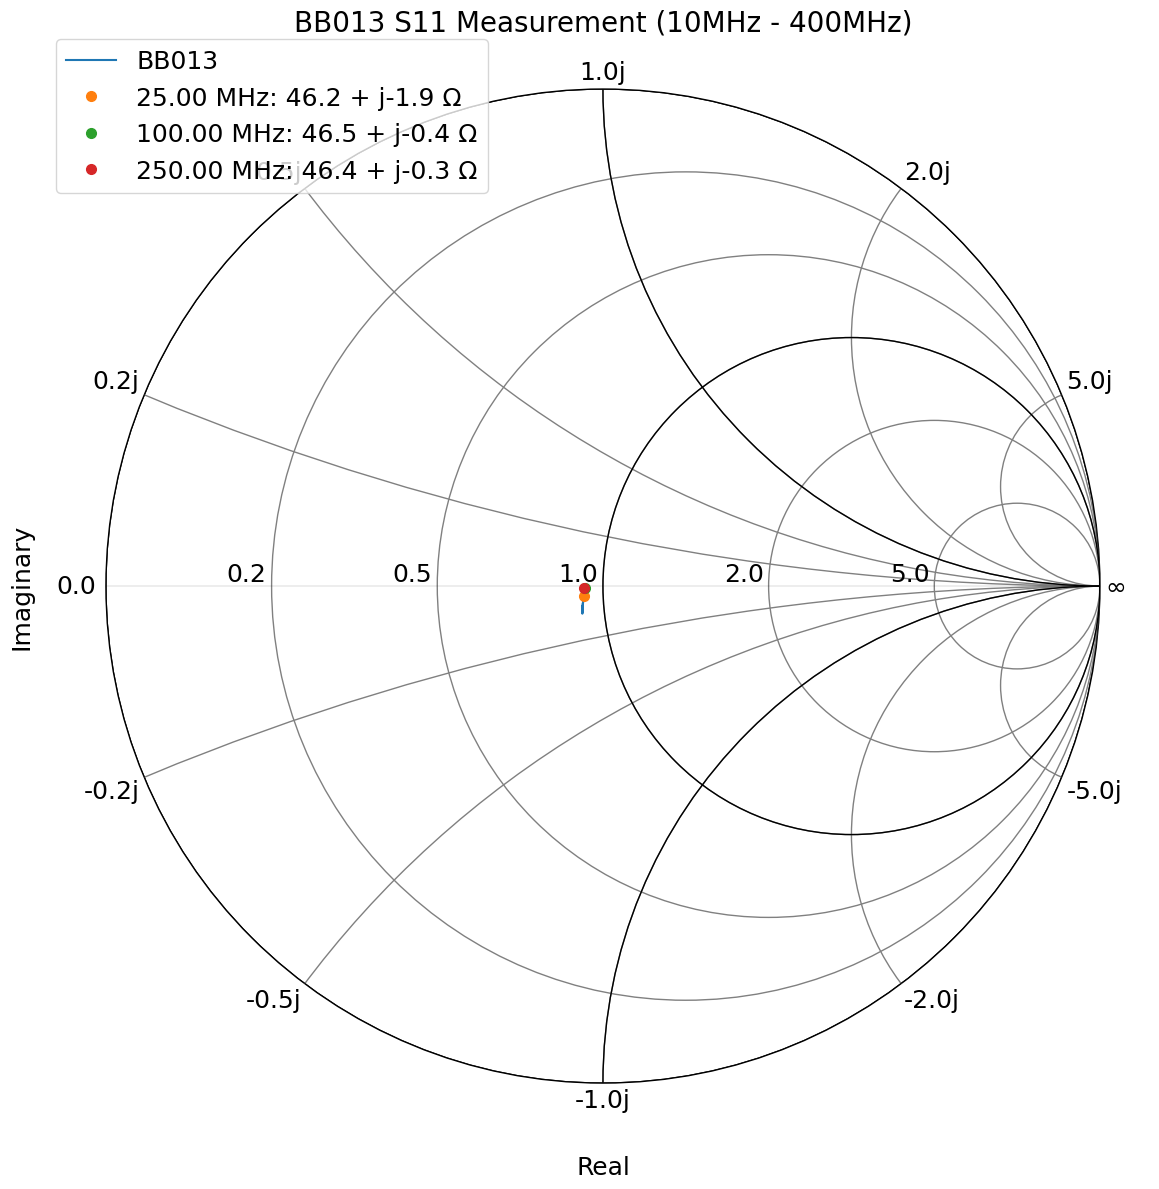

In [ ]:
# plot BB and ND s11s
BB_file = pjoin("TinyVNA_Calibration", "S11_Measurements", "BB013_on.s1p")
save_dir = pjoin("TinyVNA_Calibration", "S11_Plots")
sparam = S_Params(BB_file, labels=['BB013'])
sparam.plot_smith_chart(title='BB013 S11 Measurement (10MHz - 400MHz)',
                        save_path=pjoin(save_dir, 'BB013_smith.png'),
                        freq_range=(10e6, 400e6),
                        marker_freqs=[25e6, 100e6, 250e6])

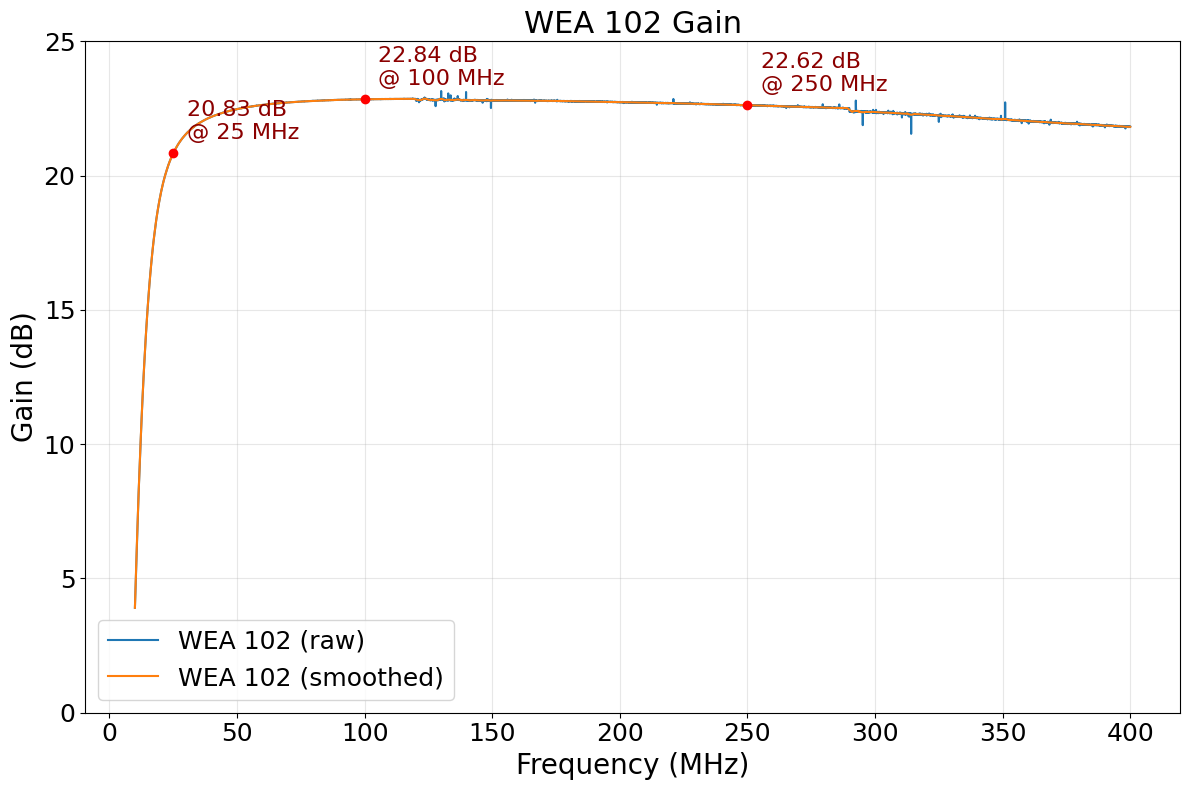

In [ ]:
# plot all s21 files
WEA_file = pjoin('S21Measurements', 'WEA102_20dB.s2p')
save_dir = pjoin('S21Measurements', 'plots')
sparam = S_Params(WEA_file, labels=['WEA 102'])
sparam.plot_gain(attenuation=20, title='WEA 102 Gain', y_range=(0, 25),
                 marker_freqs=[25, 100, 250], save_path=pjoin(save_dir, 'WEA_102_Gain.png'),
                 smoothing=True, smoothing_kwargs={'window':60})

In [4]:
# soil impedance files
soil_file = pjoin(data_dir, 'ground_impedance', '10k_500M.s1p')
nevada_file = pjoin(data_dir, 'ground_impedance', 'Nevada', 'DipoleAntennaHighResolution.s1p')
plot_dir = pjoin(data_dir, 'ground_impedance', 'plots')
sparam = S_Params([soil_file, nevada_file], labels=['Adak', 'Nevada'])
# sparam.plot_smith_chart(title='Soil Impedance (two-radial test)', save_dir=plot_dir,
#                         suffix='10k_10MHz_comparison', freq_range=(10e3, 10e6), 
#                         marker_freq=[10e3, 10e6])

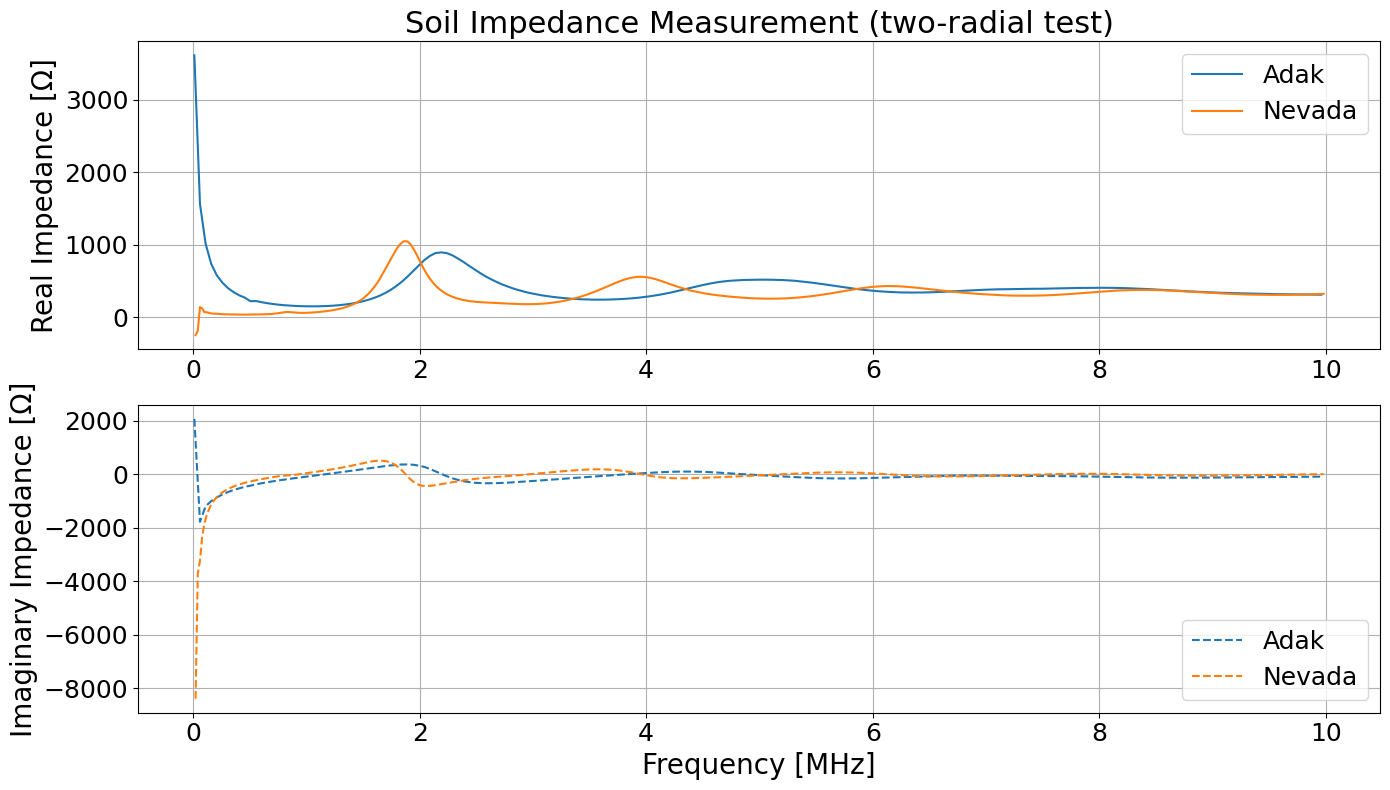

In [ ]:
sparam = S_Params([soil_file, nevada_file], labels=['Adak', 'Nevada'])
sparam.keep_freq(10e3, 10e6)
sparam.plot_impedance(title='Soil Impedance Measurement (two-radial test)',
                      save_path=pjoin(plot_dir, 'impedance_comparison.png'),
                      plot_imaginary=True)

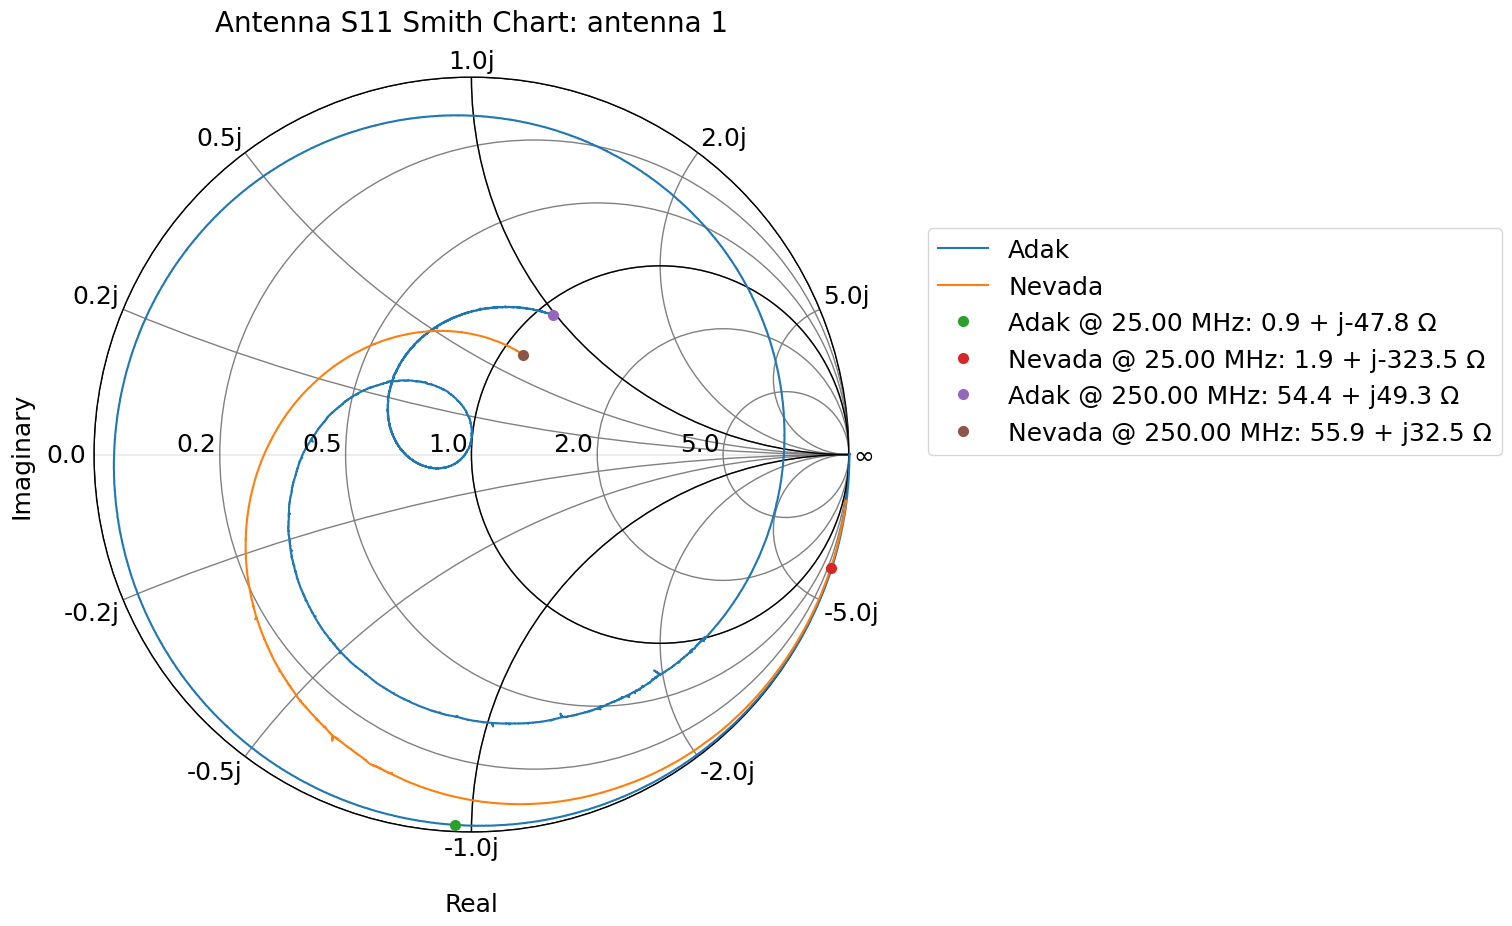

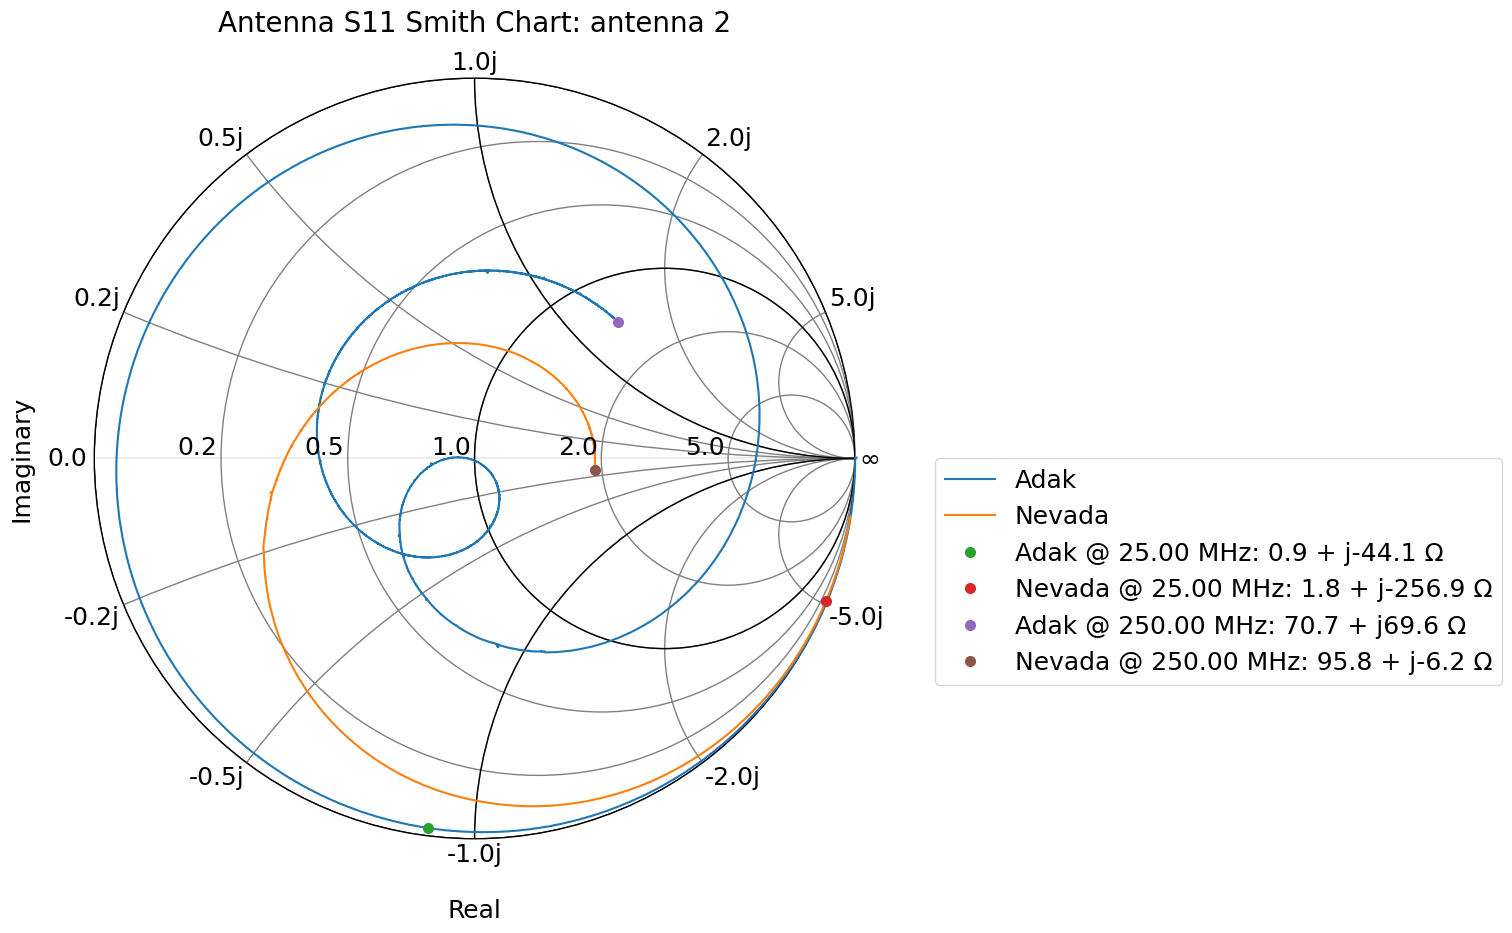

In [ ]:
# antenna files
adak_files = glob.glob(pjoin('impedance', '*.s1p'))
nevada_files = glob.glob(pjoin('antenna_S11', 'Nevada', '*.s1p'))
plot_dir = pjoin('antenna_S11', 'plots')
for i in range(1, 5):
    adak = glob.glob(pjoin('antenna_S11', f'Ant{i}_far.s1p'))[0]
    nevada = glob.glob(pjoin('antenna_S11', 'Nevada', f'antenna{i}.s1p'))[0]
    sparam = S_Params([adak, nevada], labels=[f'Adak', f'Nevada'])
    # sparam.plot_reflection_loss(db=True, title=f'Antenna S11: {os.path.basename(afile)}', ymax=0, ymin=-50, show_phase=False, attenuation=0, 
    #                            save_dir=plot_dir, suffix=afile.split('/')[-1].replace('.s1p',''))
    sparam.plot_smith_chart(title=f'Antenna S11 Smith Chart: antenna {i}',
                            save_path=pjoin(plot_dir, f'antenna_{i}_smith.png'),
                            marker_freqs=[25e6, 250e6])